# EDS 232 Machine Learning Kaggle Competition

## Predicting Dissolved Inorganic Carbon (DIC) in California Coastal Waters

Authors: Megan Hessel, Richard Montes-Lemus, Sofia Rodas, and Peter Vitale.

## Background

**This notebook tests several machine learning models to find the one that best predicts dissolved inorganic carbon (DIC) concentration (umol/kg) in seawater samples collected off the California coast.**

**The data come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI), one of the longest-running ocean monitoring programs in the world. Each row corresponds to a single water sample, described by total alkalinity (TA) (umol/kg), seawater practical salinity (ppt(PSS78)), seawater temperature (°C), depth (m), and dissolved inorganic carbon (DIC) (umol/kg).**


## Setup

In [1]:
# Load Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split,  cross_val_score, GridSearchCV
from xgboost import XGBRegressor
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

**Load** raw test & training data and **seperate** data into Xs and Ys

In [2]:
# Read in data 
train_data = pd.read_csv('data/train.csv')
test_data = pd.read_csv('data/test.csv')

In [3]:
# Extract feature names 
feature_names = ['CTDTEMP_ITS90', 'Salinity_PSS78', 'Depth', 'TA']

# Training set's X and Y
X_train = train_data.set_index('id')[feature_names]
y_train = train_data['DIC']

# Test set's X
X_test = test_data.set_index('id')[feature_names]

## Exploratory Data Analysis 

Examine the **raw data** by looking at outliers and variable distributions. 

In [4]:
# Look at the outliers
depth_outliers = train_data[train_data["Depth"] > 600]
print(depth_outliers[feature_names + ["DIC"]].describe())
print(f"\nCount: {len(depth_outliers)}")

       CTDTEMP_ITS90  Salinity_PSS78        Depth           TA          DIC
count      14.000000       14.000000    14.000000    14.000000    14.000000
mean        1.714214       34.660286  3327.928571  2427.292857  2352.250000
std         0.620636        0.055397   670.180741    18.310546     4.697913
min         1.520000       34.470000  1000.000000  2364.100000  2348.300000
25%         1.542500       34.670000  3499.000000  2430.750000  2350.025000
50%         1.550000       34.680000  3500.000000  2432.000000  2350.700000
75%         1.560000       34.680000  3504.750000  2432.925000  2351.625000
max         3.870000       34.680000  3542.000000  2437.100000  2364.600000

Count: 14


In [5]:
# Compare DIC distribution with vs without
print(f"\nDIC mean WITH outliers:    {train_data['DIC'].mean():.2f}")
print(f"DIC mean WITHOUT outliers: {train_data[train_data['Depth'] <= 600]['DIC'].mean():.2f}")


DIC mean WITH outliers:    2117.76
DIC mean WITHOUT outliers: 2116.79


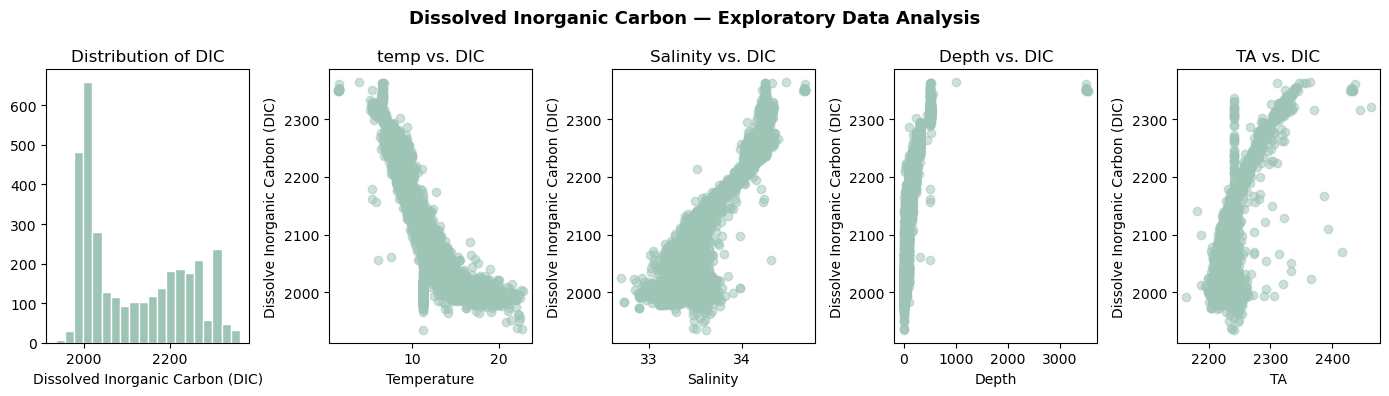

In [6]:
# Visualize data
fig, axes = plt.subplots(1, 5, figsize=(14, 4))

# --- Plot 1: DIC distribution ---
axes[0].hist(train_data['DIC'], bins=20, color='#9DC4B5', edgecolor='white')
axes[0].set_xlabel('Dissolved Inorganic Carbon (DIC)')
axes[0].set_ylabel('')
axes[0].set_title('Distribution of DIC')

# --- Plot 2: DIC vs TEMP ---
axes[1].scatter(train_data['CTDTEMP_ITS90'], train_data['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[1].set_title("temp vs. DIC")

# --- Plot 3: DIC vs Slinity ---
axes[2].scatter(train_data['Salinity_PSS78'], train_data['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[2].set_xlabel("Salinity")
axes[2].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[2].set_title("Salinity vs. DIC")

# --- Plot 4: DIC vs Depth ---
axes[3].scatter(train_data['Depth'], train_data['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[3].set_xlabel("Depth")
axes[3].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[3].set_title("Depth vs. DIC")

# --- Plot 4: DIC vs TA ---
axes[4].scatter(train_data['TA'], train_data['DIC'], alpha = 0.5, color = "#9DC4B5")
axes[4].set_xlabel("TA")
axes[4].set_ylabel("Dissolve Inorganic Carbon (DIC)")
axes[4].set_title("TA vs. DIC")

plt.suptitle('Dissolved Inorganic Carbon — Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The four predictors do not follow a clear linear relationship with the response. We'll explore different models to find the best test MSE in the Kaggle competition. 

Examine the **X and Y training vs test sets**, looking at NAs and dimensions. 

In [7]:
# Ensure NA are not present in data 
print(f"X_train NAs count:{X_train.isna().any(axis=1).sum()}")
print(f"X_test NAs count:{X_test.isna().any(axis=1).sum()}")
print(f"y_train NAs count:{X_test.isna().any(axis=1).sum()}")

X_train NAs count:0
X_test NAs count:0
y_train NAs count:0


In [8]:
# Print shape of all test and training splits 
print(f"The training predictors contain {X_train.shape[0]} rows and {X_train.shape[1]} columns")
print(f"The training response contains {y_train.shape[0]} rows")
print(f"The testing predictors contain {X_test.shape[0]} rows and {X_test.shape[1]} columns")

The training predictors contain 3389 rows and 4 columns
The training response contains 3389 rows
The testing predictors contain 848 rows and 4 columns


## Scaling

Models may perform poorly if the variables are in incompatible units. In this senerio, the varaibles are in vastly different scales and ranges. Therefore, we must scale the data, speificically the `X_train` and `X_test` to avoid data leakage.

In [9]:
# Fit the scaler ONLY on train data and transform only on X
scaler = StandardScaler().fit(X_train)

# Maintain columns 
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Print statements
print(f'Training set : {X_train_s.shape[0]:,} tracts')
print(f'Test set     : {X_test_s.shape[0]:,} tracts')

Training set : 3,389 tracts
Test set     : 848 tracts


## Ridge Regularization Model

Regulation regression model is a linear model method that prevents overfitting by adding a penalty term that shrinks the coefficients proportionally towards zero. The hyperparameter lambda controls the penalty. A large lambda cause a high penalty term that shrink coefficents towards zero; a small lambda reduced coefficents slightly while retaining model complexity. 

In [10]:
# Create lambdas list 
lambdas = np.logspace(-4,4, 100)

In [11]:
# Initalize and fit Ridge regression model
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_s, y_train)

# Evaluate and predict 
ridge_cv.alpha_
y_test_pred_rcv = ridge_cv.predict(X_test_s) # <- Submission 

In [12]:
# Store coefficients associated with each lambda fitting
coefs_ridge = []

for lam in lambdas:
    ridge = Ridge(alpha=lam) #Get a model for each lambda value 
    ridge.fit(X_train_s, y_train) # fit to trained data 
    coefs_ridge.append(ridge.coef_)

coefs_ridge = np.array(coefs_ridge)

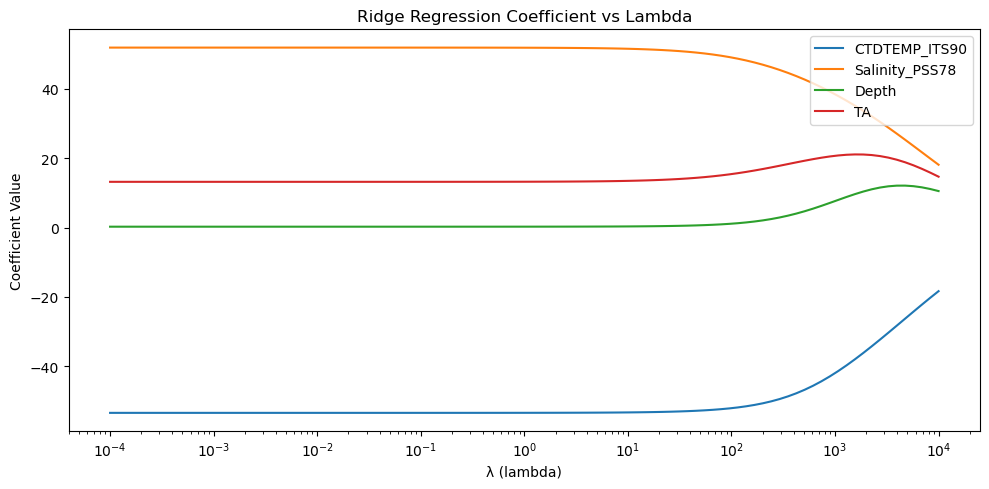

In [13]:
# Visualize lambdas for each coefficient 
plt.figure(figsize=(10, 5))

for i in range(len(feature_names)): # Feature names are in the same order as resulting coefficient table (coef)
    plt.plot(lambdas, coefs_ridge[:, i], label=feature_names[i]) # Plot feature name and associated lambda 

plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression Coefficient vs Lambda')
plt.legend()
plt.tight_layout()
plt.show()

## Lasso Regulation Model 

Lasso Regulation regression model is a linear model method that prevents overfitting by adding a penalty term that shrinks the coefficients to exactly zero. The hyperparameter lambda controls the penalty. A large lambda cause a high penalty term that can shrink coefficents to exactly zero; a small lambda reduced coefficents slightly while retaining model complexity. 

In [14]:
# Initalize and fit Lasso regression model
lasso_cv = LassoCV(alphas=lambdas, cv=10)
lasso_cv.fit(X_train_s, y_train)

# Evulate and predict 
print(f"Best Lambda: {lasso_cv.alpha_:.3f}") # best lambda
y_test_pred_lcv = lasso_cv.predict(X_test_s)  # <- Submission 

Best Lambda: 1.918


In [15]:
# Store coefficients associated with each lambda fitting
coefs_lasso = []

for lam in lambdas:
    lasso = Lasso(alpha=lam)
    lasso.fit(X_train_s, y_train)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)

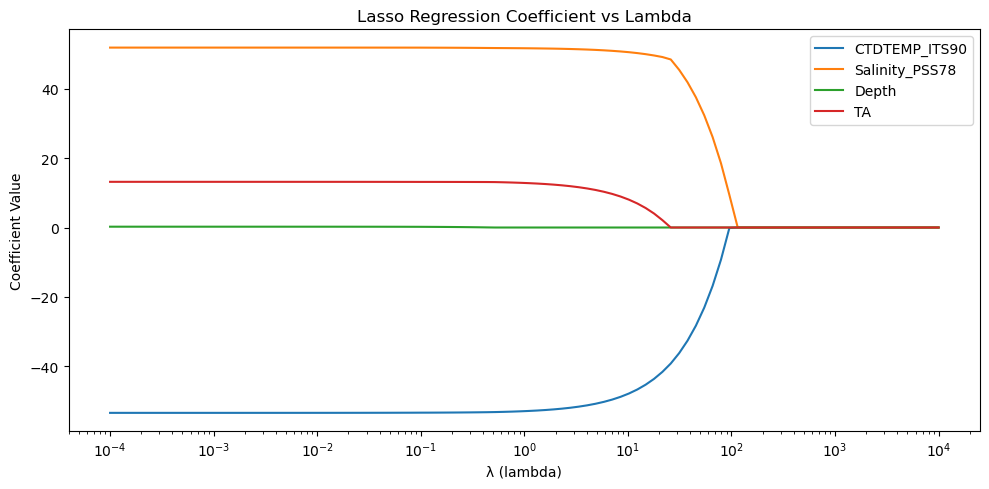

In [16]:
# Plot lasso coefficients 
plt.figure(figsize=(10, 5))

for i in range(len(feature_names)):
    plt.plot(lambdas, coefs_lasso[:, i], label=feature_names[i])

plt.xscale('log')
plt.xlabel('λ (lambda)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression Coefficient vs Lambda')
plt.legend()
plt.tight_layout()
plt.show()

## Principles Component Analysis (PCA)

PCA is machine leanring technique for dimensionality reduction. A regression model is then fit with the PCs that explain >90-95% of the cumulative variance instead of the orginal predictors. 

### Fit the Model & Inspect Variance 

In [17]:
# -- Run the model  -- 
pca = PCA(n_components=4) # Initalize 
pca_fill = pca.fit(X_train_s) # Fit 

# -- Evaluate -- 
explained_var = pca.explained_variance_ratio_ # Explained variance 
cumulative_var = np.cumsum(pca.explained_variance_ratio_) # Cumulative variance 

In [18]:
# Create a table with Explained & Cumculative variance 
pca_df= pd.DataFrame({
  'component': ['PC1', 'PC2', 'PC3', 'PC4'],
  'explained_var' : explained_var, 
  'cumulative_var' : cumulative_var
})

pca_df

,component,explained_var,cumulative_var
0,PC1,0.789091,0.789091
1,PC2,0.111665,0.900757
2,PC3,0.075478,0.976234
3,PC4,0.023766,1.000000


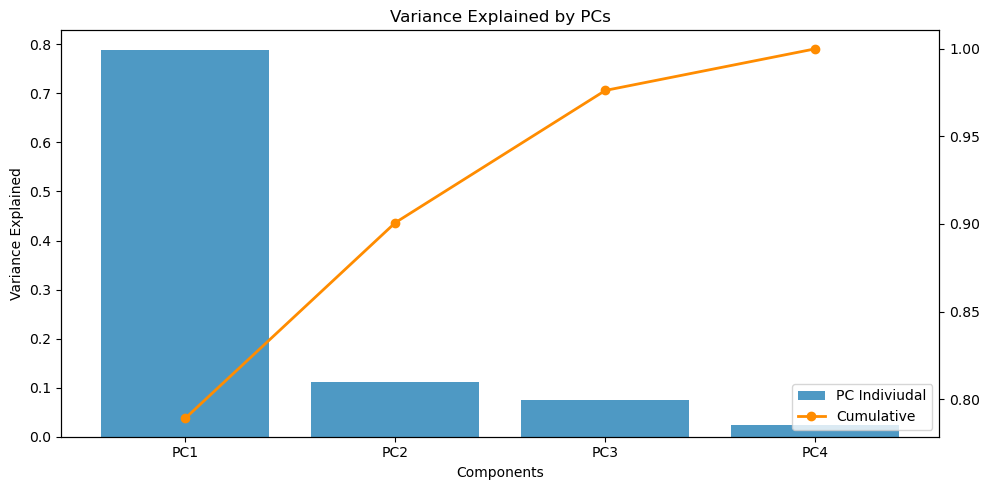

In [19]:
# Bar chart showing the individual explained variance (%) for each component
# Line plot overlaid showing the cumulative explained variance (%)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart on ax1
ax1.bar(pca_df['component'], pca_df['explained_var'], color = "#4e99c4", label='PC Indiviudal')

# Line plot (second y-axis sharing same x)
ax2 = ax1.twinx()
ax2.plot(pca_df['component'], pca_df['cumulative_var'], color = "darkorange",  marker='o', linewidth=2, label='Cumulative')

ax1.set_xlabel("Components")
ax1.set_ylabel("Variance Explained")
ax1.set_title("Variance Explained by PCs")

# Combind Legends 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'lower right')

plt.tight_layout()
plt.show()

### Fit the Final PCR Model 

The scree plots show that only 3 PCs will catch >95% of the variance. Therefore, we will now fit a regression model with 3 PCs. 

In [20]:
# Number of PCs that > 95% of the cumulative variance
best_k = 3 

In [21]:
# Initalized  
pca_final = PCA(n_components=best_k).fit(X_train_s) # Initalized  

# Compute Principle components of the standardized predictors 
X_train_pca = pca_final.transform(X_train_s) 
X_test_pca = pca_final.transform(X_test_s)

# Fit linear regression on new projected data 
ols_pcr = LinearRegression().fit(X_train_pca, y_train)

# Evaluate  
y_pred_pcr = ols_pcr.predict(X_test_pca) # <- Submission 

## Random Forest Regression 

Random Forest Regression is an ensemble machine learning technique that predicts numerical values by averaging the outputs of multiple independent decision trees. The model decorrelates the trees by randomly selecting a subsets of predictors as candiates for each split. 


In [22]:
# Grid search Parameters 
param_grid = {
    'n_estimators':      [100, 200],
    'max_features':      ['sqrt', 0.5],
    'max_depth':         [10, 20, None],
    'min_samples_leaf':  [1, 3, 5]
}

# Tune Random Forest Regression  
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit 
rf_grid.fit(X_train, y_train)

# Evaluate (with print statements)
rf_best = rf_grid.best_estimator_
print("Best parameters:", rf_grid.best_params_)

# Predict 
y_pred = rf_best.predict(X_test)  # <- Submission 

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}


## XGBoost Regression 

XGBoost is a gradient boosting ensemble method where sequential decision trees are built, with each tree correcting the residual errors of the previous one. The final prediction is the weighted sum of all trees, where the learning rate controls how much each tree contributes.

In [23]:
# For boosting we wanted a way to compare model parameters so we train test split the training set for validation

features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]
X = train_data[feature_names]
y = train_data["DIC"]

xgb_param_grid = {
    'n_estimators':   [200, 500],
    'learning_rate':  [0.05, 0.1],
    'max_depth':      [4, 6, 8],
    'subsample':      [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

X_train_xg, X_val, y_train_xg, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_grid.fit(X_train_xg, y_train_xg)

best_xgb = xgb_grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_val)

# Retrain best XGB on full training data
final_xgb = XGBRegressor(**xgb_grid.best_params_, random_state=42, n_jobs=-1)
final_xgb.fit(X, y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=200, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## Support Vector Regression (SVR)

SVR models use non-linear curves to define divisions in data based on data's high dimensions. 

### Radial Basis Function (RBF) Kernel

RBF measures similarity by distance and creates smooth regression curves in non-linear data. 

In [24]:
# Make a parameter grid for the rbf model
param_grid = {'C' : [0.1, 1, 10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100],
              'gamma' : ['scale', 0.001, 0.01, 0.1, 1, 10]}

# Define the rbf model to find the best parameters
grid_rbf = GridSearchCV(
    SVR(kernel = 'rbf'), 
    param_grid, 
    cv = 5, 
    scoring = 'r2', 
    n_jobs = -1)

# Fit the rbf model to the data 
grid_rbf.fit(X_train_s, y_train)

# Predict the test 
y_test_pred_rbf = grid_rbf.predict(X_test_s)

# Evaluate the rbf model's accuracy
rbf_best = grid_rbf.best_estimator_

print(f"Best parameters:  {grid_rbf.best_params_}")
print(f"CV R2:", {grid_rbf.best_score_})

Best parameters:  {'C': 1000, 'gamma': 1}
CV R2: {0.9508871367152046}


The best parameters for the RBF model for our data is a large C of 1000 and a gamma of 1. The large C penalizes violations. The R2 is 0.95 meaning it explains 95% of the variance in the training data. 

### Polynomial Kernel

Polynomial kernels can fit data that follow polynomial relationships. Higher degrees can capture feature interactions.

In [25]:
# Make a parameter grid for the poly model
param_grid = {'C' : [0.1, 1, 10, 100],
              'gamma' : ['scale', 0.001, 0.01, 0.1, 1],
              'degree' : [2, 3, 4, 5],
              'coef0' : [0.0, 1.0]}

# Define the poly model to find the best parameters
grid_poly = GridSearchCV(
    SVR(kernel = 'poly'), 
    param_grid, 
    cv = 5, 
    scoring = 'r2',
    n_jobs= -1)

# Fit the poly model to the data
grid_poly.fit(X_train_s, y_train)

# Predict the test 
y_test_pred_poly = grid_poly.predict(X_test_s)

# Evaluate the poly model's accuracy
poly_best = grid_poly.best_estimator_

print(f"Best parameters:  {grid_poly.best_params_}")
print(f"CV R2:", {grid_poly.best_score_})

Best parameters:  {'C': 100, 'coef0': 1.0, 'degree': 5, 'gamma': 0.01}
CV R2: {0.9143215134095979}


When tuned the polynomial kernel works best on the data when C equals 100, the coef0 is 1, the degree is 5, and gamma is 0.1. The polynomial kernel fits the data worse than the RBF kernel. It's R2 shows it explains only approximated 91% of the variance of the training data. When entering this dataset into kaggle it also performs worse on the test data.

## Light Gradient Boosting Machine (LightGBM)

Similar to XGBoost, the LightGBM model uses tree-based algorithms to create the best predictive model. The LightGBM model uses leaf-wise splitting instead of level-wise splitting. This makes asymmetric decision trees by splitting the nodes with the highest impurity or uncertainty rates.

Hyperparameters of a LightGBM:

    - n_estimators: Number of boosted trees to fit. 
    - learning_rate: How much each tree influences final predictions
    - num_leaves: How complex a tree can be/ How many leaves a tree has. 

More hyperparameters are available for tuning but these are the ones we found to be most influential on the R2. 

Using `GridSearchCV()` which iterates through all of the possible combinations of the parameters was taking too much computing power and far too long. Instead the `RandomizedSearchCV()` was utilized to test a fraction of the possible combinations of the parameters, in this case we tried 30 combinations. 

**This gave us our best score!**

In [26]:
# make a parameter grid for the lgb model
param_grid = {
    'n_estimators':   [100, 300, 500, 700, 800],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'num_leaves':     [10, 20, 31, 50] # for some reason 31 is used in most of the documentation
}

# define the lgb model to find the best parameters
grid_lgb = RandomizedSearchCV(
    lgb.LGBMRegressor(verbose= -1, # controls logging information which -1 stops altogether
                      n_jobs = 1),
    param_grid,
    n_iter=30,       # 30 random combos 
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# fit the lgb model to the data 
grid_lgb.fit(X_train_s, y_train)

# predict the test 
y_test_pred_lgb = grid_lgb.predict(X_test_s)

# access the lgb model's accuracy
lgb_best = grid_lgb.best_estimator_

print(f"Best parameters: {grid_lgb.best_params_}")
print(f"CV R2: {grid_lgb.best_score_:.4f}")  

Best parameters: {'num_leaves': 31, 'n_estimators': 100, 'learning_rate': 0.1}
CV R2: 0.9751


The `RandomSearchCV()` found the R2 is best for the LightGBM model when the number of leaves is 31, the number of boosted trees is 100, and the learning rate is 0.1.

## Model Comparsion 

We compared our models' results side by side and commented on which performed best, why we though that was the case, and which models we decided to go with.

In [28]:
# Compare models and there MSE scores 
pd.DataFrame({
  'Models': ['Ridge', 'Lasso', 'PCA', 'Random_Forest', 'Boost', 'SVR_Polynomal', 'SVR_RBF', 'LightGBM'],
  'Test MSE' : [1587.76, 1590.89, 
           1647.35, 225.80, 229.69, 389.86, 1042.73, 211.01], 
})


,Models,Test MSE
0,Ridge,1587.76
1,Lasso,1590.89
2,PCA,1647.35
3,Random_Forest,225.80
4,Boost,229.69
5,SVR_Polynomal,389.86
6,SVR_RBF,1042.73
7,LightGBM,211.01



The LightGBM model is an ensemble model that uses decision trees to find the best fit for the data. The LightGBM model performed the best because it utilizes leaf-wise splitting instead of level-wise splitting. This gives the model more flexibility to fit the data where it has a high MSE but doesn't overfit where it already achieved a low MSE. The hyperparameters for the LightGBM allow for fine tuning of the number of trees to use in the model, the amount of weight each tree has on final predictions, and how complex a tree is. 

The Random Forest model performed second best, achieving a marginally lower MSE than XGBoost on the Kaggle leaderboard. The XGBoost model performed third, as it is another gradient boosting ensemble model that uses sequential decision trees, where each tree corrects the residual errors of the previous one. Unlike LightGBM, XGBoost uses level-wise splitting, expanding all leaves at a given depth before growing deeper, which is more conservative but offers less flexibility in fitting complex local patterns. Blending the Random Forest and XGBoost predictions resulted in a lower MSE than either model alone, suggesting the models were making different errors and compensating for each other.

Ridge, Lasso, and PCA regularization models were some of the worst performing. This is likely because these models are limited to linear relationships between the predictors and response. Temperature, depth, salinity, and TA all show non-linear patterns with DIC. The LightGBM and Random Forest models are appropriate for non-linear relationships, therefore they achieved a lower MSE.

PCA performed the worst overall, this is probably because reducing to 3 components discarded information relevant to predicting DIC. SVR with the RBF kernel outperformed the linear models but were worse than the tree-based ensembles, this may suggest the kernel captured some non-linearity but did not have the flexibility of boosting methods. We submitted the LightGBM predictions to Kaggle as our final model!

# References

GeeksforGeeks. (2025). Lightgbm tree parameters. Retrieved from https://www.geeksforgeeks.org/machine-learning/lightgbm-tree-parameters/ 

GeeksforGeeks. (2025). Regression using lightgbm. Retrieved from https://www.geeksforgeeks.org/machine-learning/regression-using-lightgbm/ 

Shekarreddy. (2024). RandomizedSearchCV. Retrieved from https://medium.com/@shekar3reddy4/randomizedsearchcv-3fac09d6927e 

Zouinina, S. (2024). A deep dive into LIGHTGBM: How to choose and tune parameters. Retrieved from https://medium.com/@sarahzouinina/a-deep-dive-into-lightgbm-how-to-choose-and-tune-parameters-7c584945842e 